## Problema - Organización y búsqueda de productos en una tienda




In [78]:
# @title Ingrese datos
nombre_estudiante = "Andres Felipe Marin Velez" 
carnet = 1000112123


## 1) Descripción del problema **[1 pts]**

Una tienda necesita organizar de manera eficiente la atención de sus clientes y la administración de sus productos. Para ello, se requiere implementar diferentes estructuras de datos que permitan controlar el orden de atención, registrar las operaciones realizadas y gestionar el catálogo de productos. La solución utiliza una cola FIFO para atender a los clientes en el mismo orden en que llegan, una pila LIFO para guardar el historial de clientes atendidos y permitir deshacer la última atención, y una lista doblemente enlazada para almacenar productos, recorrerlos en ambos sentidos, buscarlos y eliminarlos mediante su código. De esta forma, el sistema permite representar de manera práctica el funcionamiento de colas, pilas y listas enlazadas dentro de un mismo escenario.



## 2) Requerimientos
**Requerimentos funcionales:**

RQF1: El programa debe permitir agregar un nuevo cliente a la cola

RQF2: El sistema debe atender cliente por cliente en orden de llegada

RQF3: El sistema debe agregar a una pila cada cliente atendido

RQF4: El sistema debe deshacer la ultima atencion

RQF5: el sistema debe mostrar todos los productos en una lista enlazada

RQF6: El sistema debe poder buscar un producto utilizando su codigo


**Requerimentos no funcionales:**

RQNF1 (Rendimiento): El sistema debe responder de forma rápida y optimizar el uso de memoria y procesador.

RQNF2 (Estructuras): La segunda parte debe usar listas dinámicas para manejar los datos.

RQNF3 (Búsqueda): La búsqueda de productos debe usar una lista doblemente enlazada para recorrer los datos hacia adelante y hacia atrás.

RQNF4 (Transparencia): El sistema debe mostrar el progreso de cada operación paso a paso en pantalla o en registros.


## 3) Historias de usuario 

**Historia de usuario 1**

Como usuario de la tienda, quiero registrar clientes, agregar nuevos clientes y atenderlos en el orden en que llegan, para mantener organizada la fila de atención.
Criterios de aceptación:

•	Los clientes deben conservar el orden en que fueron registrados.

•	Los nuevos clientes deben agregarse al final de la fila.

•	Al atender un cliente, debe retirarse el primero de la fila.

•	Se deben poder visualizar los clientes que continúan esperando.

Escenario:

Dado que la fila contiene Ana, Carlos, Laura y Mateo, cuando se atiende al siguiente cliente, entonces Ana debe salir de la fila y deben quedar Carlos, Laura y Mateo. Si posteriormente llega Sofía, debe agregarse al final de la fila.

**Historia de usuario 2**

Como usuario de la tienda, quiero consultar el último cliente atendido y deshacer la última atención, para poder corregir una atención realizada por error.
Criterios de aceptación:

•	Cada cliente atendido debe quedar registrado en el historial.

•	Se debe poder consultar el último cliente atendido.

•	Al deshacer una atención, el último cliente debe retirarse del historial.

•	El cliente cuya atención fue deshecha debe regresar al inicio de la fila.

Escenario:

Dado que se han atendido Ana, Carlos y Laura, cuando el usuario consulta el último cliente atendido, entonces debe mostrarse Laura. Si se deshace la última atención, Laura debe eliminarse del historial y regresar al inicio de la fila de espera.

**Historia de usuario 3:**

Como usuario de la tienda, quiero agregar, consultar, buscar y eliminar productos,
para mantener organizado y actualizado el catálogo de la tienda.
Criterios de aceptación:

•	Cada producto debe tener código, nombre y precio.

•	Los productos deben poder visualizarse desde el primero hasta el último.

•	También deben poder visualizarse desde el último hasta el primero.

•	Se debe poder buscar un producto mediante su código.

•	Se debe poder eliminar un producto mediante su código.

Escenario:

Dado que el catálogo contiene Arroz, Leche, Pan y Café con códigos 101, 102, 103 y 104, cuando se busca el código 103, debe mostrarse el producto Pan. Si se elimina el código 103, Pan debe desaparecer y el catálogo debe quedar con Arroz, Leche y Café.



## 4) Diagramas de flujo 
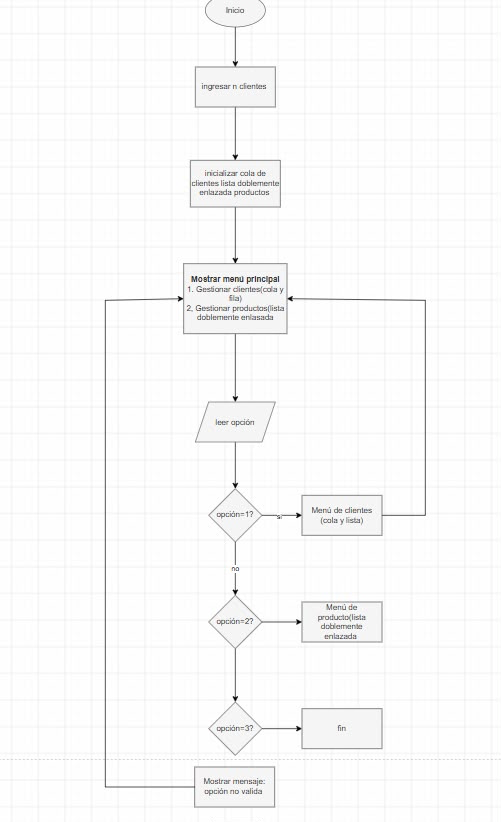


## 5) Diagramas de secuencia **[5 pts]**
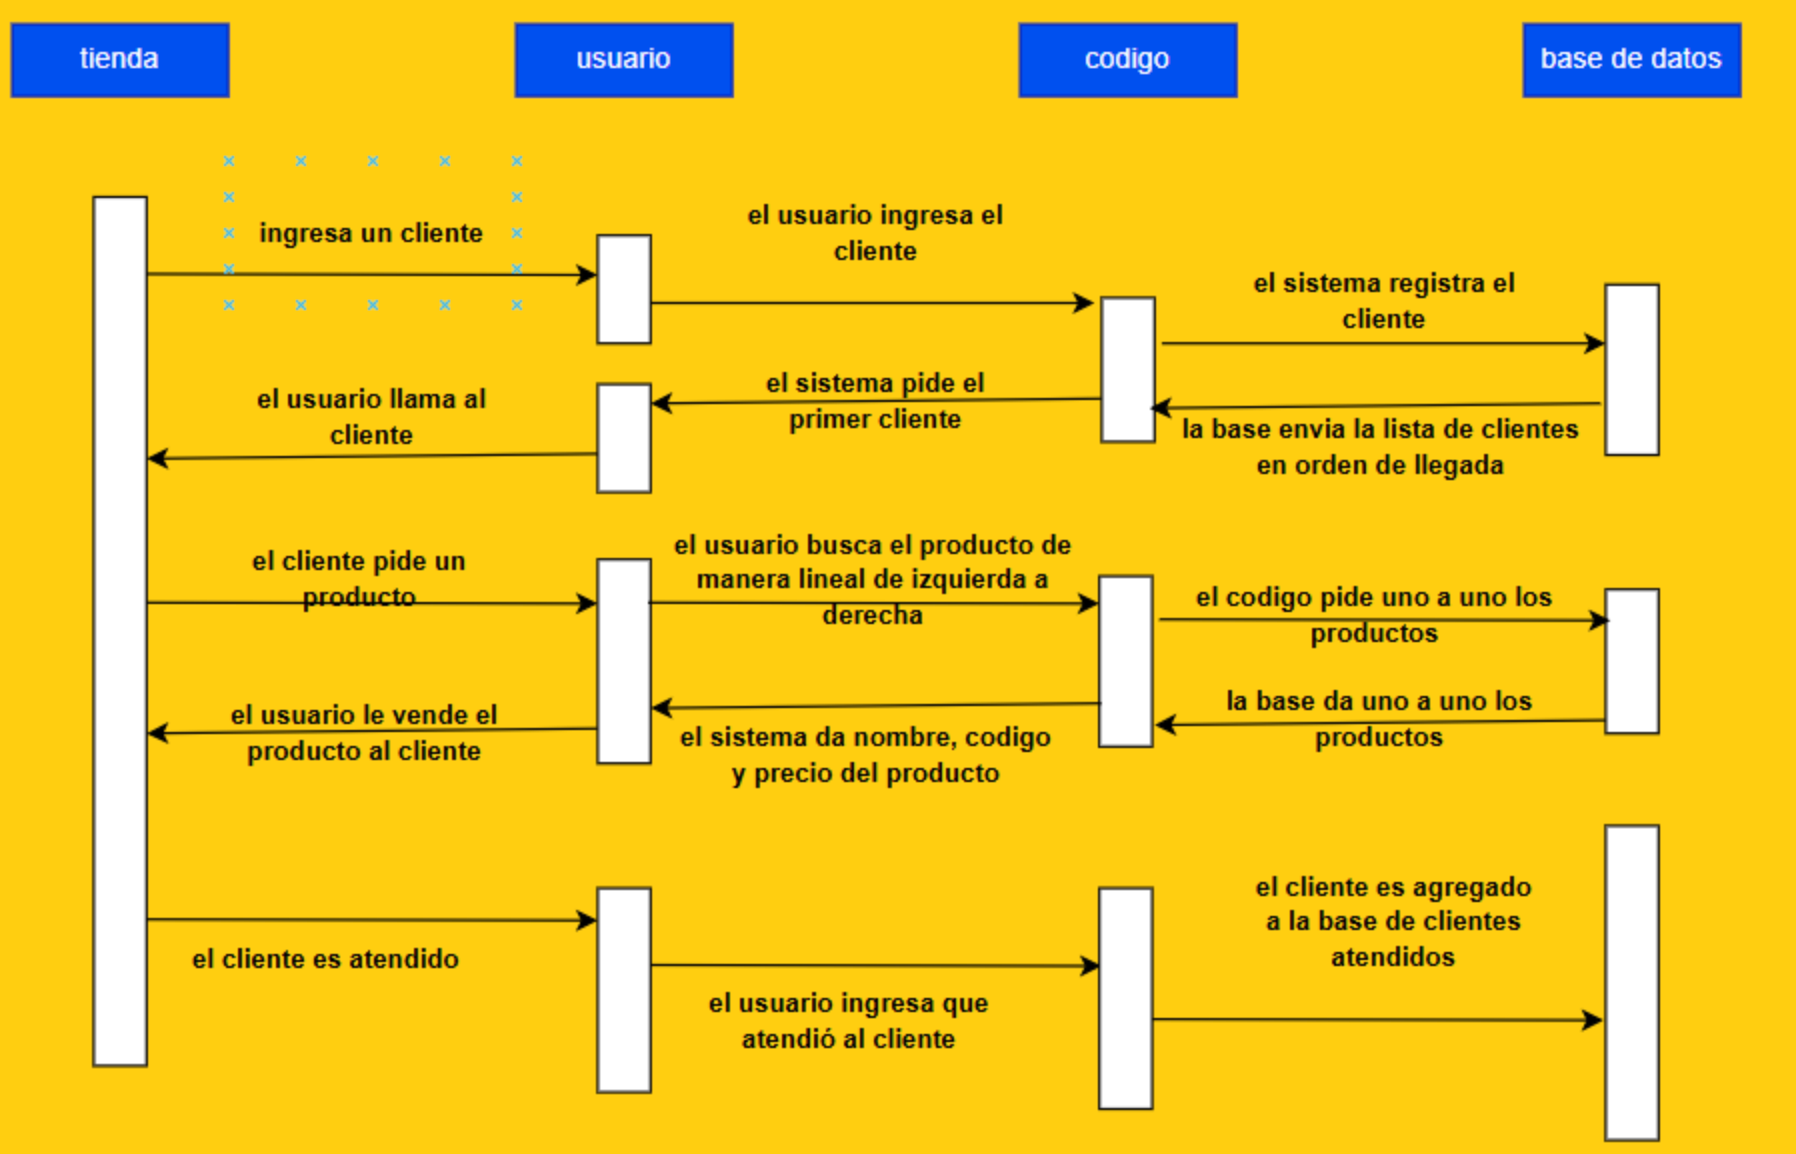


## 6) Diagramas de casos de uso 

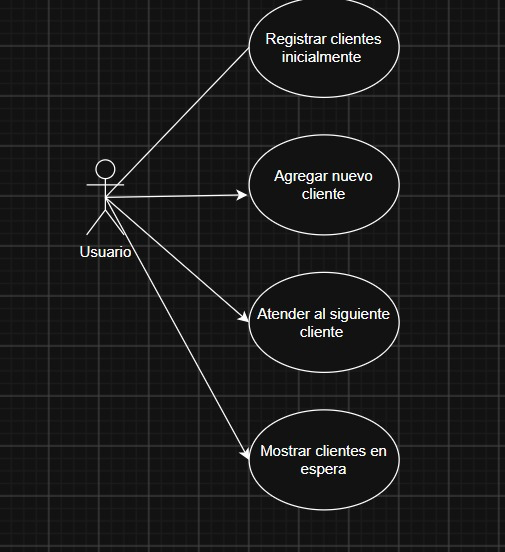
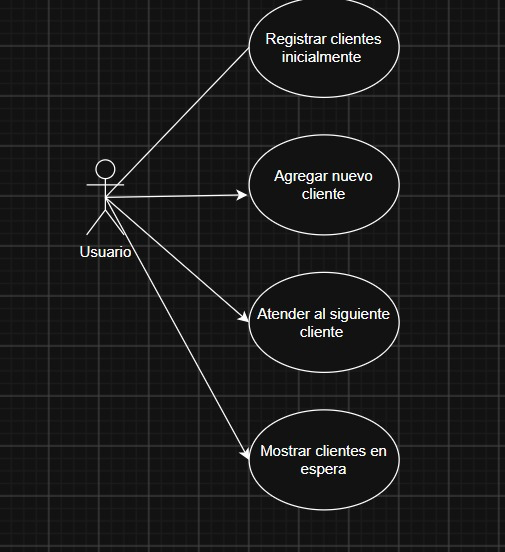
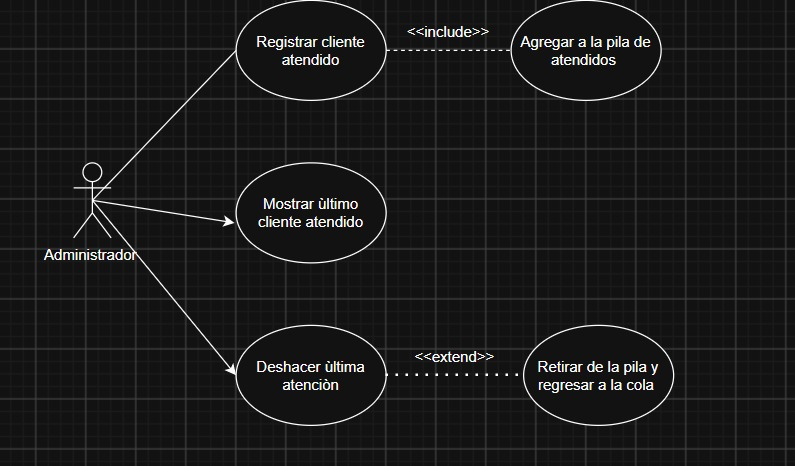

## 7) Análisis de complejidad 

### Complejidad de las estructuras

| Operación | Estructura | Complejidad |
|---|---|---:|
| Consultar primero / TOP | Cola o pila | O(1) conceptualmente |
| PUSH / POP | Pila | O(1) conceptualmente |
| Recorrer todos los clientes | Cola o pila | O(n) |
| Agregar producto al final | Lista doble | O(n) en este código* |
| Recorrer productos | Lista doble | O(n) |
| Buscar producto por código | Lista doble | O(n) |
| Eliminar por código | Lista doble | O(n) |

En conclusión, las operaciones más eficientes del sistema tienen complejidad O(1), ya que se realizan en tiempo constante, mientras que las operaciones que requieren recorrer los elementos pueden llegar a O(n) en el peor caso.




## 8) Código funcional 

### Puntos 1 y 2 — Cola de clientes + pila de atenciones


In [79]:
# ============================================================
# BLOQUE 1. IMPORTACIÓN DE LIBRERÍAS
# ============================================================
#
# El bloque intenta importar ipywidgets.
# Si el entorno de Jupyter no la tiene instalada,
# la instala automáticamente una sola vez.
# ============================================================

import sqlite3
import sys
import subprocess

try:
    import ipywidgets as widgets
except ModuleNotFoundError:
    print("Instalando ipywidgets...")
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "ipywidgets",
        "-q"
    ])
    import ipywidgets as widgets

from IPython.display import display

print("Librerías cargadas correctamente.")


Librerías cargadas correctamente.


In [80]:
# ============================================================
# BLOQUE 2. BASE DE DATOS DE CLIENTES
# ============================================================
#
# estado:
#   pendiente -> cliente en la cola
#   atendido  -> cliente en la pila
#
# orden_cola:
#   conserva el orden de llegada.
#
# orden_pila:
#   conserva el orden de atención.
#   El número mayor es el TOP.
# ============================================================

conexion = sqlite3.connect(":memory:")
conexion.row_factory = sqlite3.Row

conexion.execute("""
    CREATE TABLE clientes (
        id_cliente INTEGER PRIMARY KEY,
        nombre TEXT NOT NULL,
        estado TEXT NOT NULL
            CHECK (estado IN ('pendiente', 'atendido')),
        orden_cola INTEGER NOT NULL UNIQUE,
        orden_pila INTEGER UNIQUE
    )
""")

conexion.execute("""
    CREATE INDEX idx_clientes_cola
    ON clientes(estado, orden_cola)
""")

conexion.execute("""
    CREATE INDEX idx_clientes_pila
    ON clientes(estado, orden_pila)
""")

conexion.commit()


def reiniciar_clientes(nombres):
    """Borra la información actual y crea una nueva cola."""

    nombres_limpios = []

    for nombre in nombres:
        nombre = nombre.strip()

        if nombre:
            nombres_limpios.append(nombre)

    if not nombres_limpios:
        return False

    conexion.execute("DELETE FROM clientes")

    datos = []

    for orden, nombre in enumerate(nombres_limpios, start=1):
        datos.append(
            (nombre, "pendiente", orden, None)
        )

    conexion.executemany("""
        INSERT INTO clientes
            (nombre, estado, orden_cola, orden_pila)
        VALUES (?, ?, ?, ?)
    """, datos)

    conexion.commit()
    return True


# Ejemplo inicial del enunciado.
reiniciar_clientes(["Ana", "Carlos", "Laura", "Mateo"])

print("Base preparada.")
print("Cola inicial: Ana -> Carlos -> Laura -> Mateo")


Base preparada.
Cola inicial: Ana -> Carlos -> Laura -> Mateo


In [81]:
# ============================================================
# BLOQUE 3. PUNTO 1: COLA DE CLIENTES
# ============================================================

def obtener_pendientes():
    """Devuelve los clientes pendientes en orden FIFO."""

    return conexion.execute("""
        SELECT *
        FROM clientes
        WHERE estado = 'pendiente'
        ORDER BY orden_cola ASC
    """).fetchall()


def agregar_cliente(nombre):
    """ENQUEUE: agrega un cliente al FINAL de la cola."""

    nombre = nombre.strip()

    if nombre == "":
        return False

    fila = conexion.execute("""
        SELECT COALESCE(MAX(orden_cola), 0) + 1 AS siguiente
        FROM clientes
    """).fetchone()

    nuevo_orden = fila["siguiente"]

    conexion.execute("""
        INSERT INTO clientes
            (nombre, estado, orden_cola, orden_pila)
        VALUES (?, 'pendiente', ?, NULL)
    """, (nombre, nuevo_orden))

    conexion.commit()
    return True


def siguiente_cliente():
    """PEEK de la cola: consulta el primero sin retirarlo."""

    return conexion.execute("""
        SELECT *
        FROM clientes
        WHERE estado = 'pendiente'
        ORDER BY orden_cola ASC
        LIMIT 1
    """).fetchone()


# ============================================================
# BLOQUE 4. PUNTO 2: PILA DE ATENCIONES
# ============================================================

def obtener_atendidos():
    """Devuelve la pila desde el TOP hacia abajo."""

    return conexion.execute("""
        SELECT *
        FROM clientes
        WHERE estado = 'atendido'
        ORDER BY orden_pila DESC
    """).fetchall()


def top_cliente():
    """TOP / PEEK: consulta el último atendido."""

    return conexion.execute("""
        SELECT *
        FROM clientes
        WHERE estado = 'atendido'
        ORDER BY orden_pila DESC
        LIMIT 1
    """).fetchone()


def push_cliente(cliente):
    """PUSH: coloca un cliente atendido en el TOP."""

    tope = top_cliente()

    if tope is None:
        nuevo_orden = 1
    else:
        nuevo_orden = tope["orden_pila"] + 1

    conexion.execute("""
        UPDATE clientes
        SET estado = 'atendido',
            orden_pila = ?
        WHERE id_cliente = ?
    """, (nuevo_orden, cliente["id_cliente"]))

    conexion.commit()


def atender_siguiente_cliente():
    """
    DEQUEUE + PUSH:
    toma el primero de la cola y lo coloca en el TOP de la pila.
    """

    cliente = siguiente_cliente()

    if cliente is None:
        return None

    push_cliente(cliente)
    return cliente


def pop_cliente():
    """
    POP:
    retira el TOP y devuelve ese cliente a pendientes.
    """

    cliente = top_cliente()

    if cliente is None:
        return None

    conexion.execute("""
        UPDATE clientes
        SET estado = 'pendiente',
            orden_pila = NULL
        WHERE id_cliente = ?
    """, (cliente["id_cliente"],))

    conexion.commit()

    return cliente


In [82]:
# ============================================================
# BLOQUE 5. INTERFAZ DE LOS PUNTOS 1 Y 2
# ============================================================

# ---------- CARGA INICIAL ----------

cantidad_inicial = widgets.IntText(
    value=4,
    description="Cantidad:"
)

nombres_iniciales = widgets.Textarea(
    value="Ana\nCarlos\nLaura\nMateo",
    description="Nombres:",
    layout=widgets.Layout(width="420px", height="110px")
)

boton_crear_cola = widgets.Button(
    description="Crear / reiniciar cola",
    button_style="info",
    layout=widgets.Layout(width="210px")
)

# ---------- PUNTO 1 ----------

entrada_cliente = widgets.Text(
    description="Cliente:",
    placeholder="Ejemplo: Sofia",
    layout=widgets.Layout(width="320px")
)

boton_agregar = widgets.Button(
    description="Agregar cliente",
    button_style="primary",
    layout=widgets.Layout(width="170px")
)

boton_atender = widgets.Button(
    description="Atender siguiente",
    button_style="success",
    layout=widgets.Layout(width="170px")
)

boton_mostrar_cola = widgets.Button(
    description="Mostrar cola",
    layout=widgets.Layout(width="150px")
)

# ---------- PUNTO 2 ----------

boton_top = widgets.Button(
    description="Mostrar último atendido",
    layout=widgets.Layout(width="210px")
)

boton_deshacer = widgets.Button(
    description="Deshacer última atención",
    button_style="warning",
    layout=widgets.Layout(width="220px")
)

# ---------- SALIDAS ----------

lista_pendientes = widgets.Textarea(
    disabled=True,
    layout=widgets.Layout(width="100%", height="180px")
)

lista_atendidos = widgets.Textarea(
    disabled=True,
    layout=widgets.Layout(width="100%", height="180px")
)

texto_top = widgets.Label()
mensaje_clientes = widgets.Label()


def actualizar_clientes(aviso=""):
    """Actualiza las listas visibles."""

    pendientes = obtener_pendientes()

    nombres = []

    for cliente in pendientes:
        nombres.append(cliente["nombre"])

    lista_pendientes.value = (
        "\n".join(nombres)
        if nombres
        else "(Cola vacía)"
    )

    atendidos = obtener_atendidos()

    nombres = []

    for cliente in atendidos:
        nombres.append(cliente["nombre"])

    if nombres:
        nombres[0] += "  ← TOP"

    lista_atendidos.value = (
        "\n".join(nombres)
        if nombres
        else "(Pila vacía)"
    )

    tope = top_cliente()

    if tope is None:
        texto_top.value = "TOP / PEEK: pila vacía."
    else:
        texto_top.value = f"TOP / PEEK: {tope['nombre']}"

    mensaje_clientes.value = aviso


def crear_cola_desde_interfaz(boton):
    nombres = nombres_iniciales.value.splitlines()

    nombres = [
        nombre.strip()
        for nombre in nombres
        if nombre.strip()
    ]

    if cantidad_inicial.value <= 0:
        actualizar_clientes(
            "La cantidad debe ser mayor que cero."
        )
        return

    if len(nombres) != cantidad_inicial.value:
        actualizar_clientes(
            f"Escribiste {len(nombres)} nombres, "
            f"pero indicaste n = {cantidad_inicial.value}."
        )
        return

    reiniciar_clientes(nombres)

    actualizar_clientes(
        f"Cola creada con {len(nombres)} clientes."
    )


def agregar_desde_interfaz(boton):
    nombre = entrada_cliente.value.strip()

    if not agregar_cliente(nombre):
        actualizar_clientes(
            "Escribe un nombre antes de agregar."
        )
        return

    entrada_cliente.value = ""

    actualizar_clientes(
        f"ENQUEUE: {nombre} fue agregado al final."
    )


def atender_desde_interfaz(boton):
    cliente = atender_siguiente_cliente()

    if cliente is None:
        actualizar_clientes(
            "No hay clientes pendientes."
        )
        return

    actualizar_clientes(
        f"DEQUEUE + PUSH: se atendió a {cliente['nombre']}."
    )


def mostrar_cola_desde_interfaz(boton):
    actualizar_clientes(
        "Se actualizó la cola."
    )


def mostrar_top_desde_interfaz(boton):
    cliente = top_cliente()

    if cliente is None:
        actualizar_clientes(
            "TOP / PEEK: pila vacía."
        )
    else:
        actualizar_clientes(
            f"TOP / PEEK: {cliente['nombre']}."
        )


def deshacer_desde_interfaz(boton):
    cliente = pop_cliente()

    if cliente is None:
        actualizar_clientes(
            "No hay atenciones para deshacer."
        )
        return

    actualizar_clientes(
        f"POP: {cliente['nombre']} regresó al inicio de la cola."
    )


boton_crear_cola.on_click(crear_cola_desde_interfaz)
boton_agregar.on_click(agregar_desde_interfaz)
boton_atender.on_click(atender_desde_interfaz)
boton_mostrar_cola.on_click(mostrar_cola_desde_interfaz)
boton_top.on_click(mostrar_top_desde_interfaz)
boton_deshacer.on_click(deshacer_desde_interfaz)

panel_cola = widgets.VBox([
    widgets.HTML("<h4>Punto 1 — Cola (FIFO)</h4>"),
    widgets.Label("Clientes pendientes:"),
    lista_pendientes,
    widgets.HBox([entrada_cliente, boton_agregar]),
    widgets.HBox([boton_atender, boton_mostrar_cola])
], layout=widgets.Layout(width="49%"))

panel_pila = widgets.VBox([
    widgets.HTML("<h4>Punto 2 — Pila (LIFO)</h4>"),
    widgets.Label("Clientes atendidos:"),
    lista_atendidos,
    texto_top,
    widgets.HBox([boton_top, boton_deshacer])
], layout=widgets.Layout(width="49%"))

interfaz_clientes = widgets.VBox([
    widgets.HTML("<h3>Sistema de atención de clientes</h3>"),
    widgets.HTML("<b>Carga inicial</b>"),
    widgets.HBox([
        cantidad_inicial,
        nombres_iniciales,
        boton_crear_cola
    ]),
    widgets.HBox([panel_cola, panel_pila]),
    mensaje_clientes
])

actualizar_clientes("Sistema listo.")
display(interfaz_clientes)


### Punto 3 — Lista doblemente enlazada de productos

Cada nodo almacena:

- código
- nombre
- precio
- referencia al nodo anterior
- referencia al nodo siguiente


In [83]:
# ============================================================
# BLOQUE 1. NODO DE PRODUCTO
# ============================================================

class NodoProducto:
    """Representa un nodo de la lista doblemente enlazada."""

    def __init__(self, codigo, nombre, precio):
        self.codigo = codigo
        self.nombre = nombre
        self.precio = precio

        self.anterior = None
        self.siguiente = None


# ============================================================
# BLOQUE 2. LISTA DOBLEMENTE ENLAZADA
# ============================================================

class ListaDobleProductos:

    def __init__(self):
        self.primero = None
        self.ultimo = None


    def esta_vacia(self):
        return self.primero is None


    def buscar(self, codigo):
        """SEARCH: busca un producto por su código."""

        actual = self.primero

        while actual is not None:

            if actual.codigo == codigo:
                return actual

            actual = actual.siguiente

        return None


    def agregar_final(self, codigo, nombre, precio):
        """INSERT: agrega un producto al final."""

        if self.buscar(codigo) is not None:
            return False

        nuevo = NodoProducto(
            codigo,
            nombre,
            precio
        )

        # Lista vacía.
        if self.primero is None:
            self.primero = nuevo
            self.ultimo = nuevo

        # Lista con uno o más nodos.
        else:
            nuevo.anterior = self.ultimo
            self.ultimo.siguiente = nuevo
            self.ultimo = nuevo

        return True


    def recorrer_adelante(self):
        """Recorre del primero al último."""

        productos = []
        actual = self.primero

        while actual is not None:
            productos.append(actual)
            actual = actual.siguiente

        return productos


    def recorrer_atras(self):
        """Recorre del último al primero."""

        productos = []
        actual = self.ultimo

        while actual is not None:
            productos.append(actual)
            actual = actual.anterior

        return productos


    def eliminar(self, codigo):
        """DELETE: elimina un producto por su código."""

        nodo = self.buscar(codigo)

        if nodo is None:
            return False

        # Si era el primero.
        if nodo.anterior is None:
            self.primero = nodo.siguiente

        else:
            nodo.anterior.siguiente = nodo.siguiente

        # Si era el último.
        if nodo.siguiente is None:
            self.ultimo = nodo.anterior

        else:
            nodo.siguiente.anterior = nodo.anterior

        # Se desconecta el nodo eliminado.
        nodo.anterior = None
        nodo.siguiente = None

        return True


In [84]:
# ============================================================
# BLOQUE 3. CATÁLOGO INICIAL
# ============================================================

catalogo = ListaDobleProductos()

catalogo.agregar_final(101, "Arroz", 4500)
catalogo.agregar_final(102, "Leche", 3800)
catalogo.agregar_final(103, "Pan", 2500)
catalogo.agregar_final(104, "Café", 12000)


def precio_cop(precio):
    """Convierte 4500 en $4.500."""

    return f"${precio:,.0f}".replace(",", ".")


def texto_producto(producto):
    return (
        f"{producto.codigo} - "
        f"{producto.nombre} - "
        f"{precio_cop(producto.precio)}"
    )


def cadena_lista(productos):
    """Crea la vista NULL <- A <-> B -> NULL."""

    if not productos:
        return "NULL"

    nombres = []

    for producto in productos:
        nombres.append(producto.nombre)

    return (
        "NULL <- "
        + " <-> ".join(nombres)
        + " -> NULL"
    )


print("Catálogo inicial:")
print(cadena_lista(catalogo.recorrer_adelante()))


Catálogo inicial:
NULL <- Arroz <-> Leche <-> Pan <-> Café -> NULL


In [85]:
# ============================================================
# BLOQUE 4. INTERFAZ DEL PUNTO 3
# ============================================================

entrada_codigo = widgets.IntText(
    description="Código:",
    value=105
)

entrada_nombre_producto = widgets.Text(
    description="Nombre:",
    placeholder="Ejemplo: Huevos"
)

entrada_precio = widgets.IntText(
    description="Precio:",
    value=5000
)

boton_agregar_producto = widgets.Button(
    description="Agregar al final",
    button_style="success",
    layout=widgets.Layout(width="180px")
)

boton_adelante = widgets.Button(
    description="Primero → último",
    layout=widgets.Layout(width="180px")
)

boton_atras = widgets.Button(
    description="Último → primero",
    layout=widgets.Layout(width="180px")
)

boton_buscar_producto = widgets.Button(
    description="Buscar código",
    button_style="info",
    layout=widgets.Layout(width="170px")
)

boton_eliminar_producto = widgets.Button(
    description="Eliminar código",
    button_style="danger",
    layout=widgets.Layout(width="170px")
)

salida_productos = widgets.Textarea(
    disabled=True,
    layout=widgets.Layout(width="100%", height="230px")
)

mensaje_productos = widgets.Label()


def mostrar_lista_adelante(aviso=""):
    productos = catalogo.recorrer_adelante()

    lineas = [
        "RECORRIDO: PRIMERO -> ÚLTIMO",
        cadena_lista(productos),
        ""
    ]

    for producto in productos:
        lineas.append(texto_producto(producto))

    salida_productos.value = "\n".join(lineas)
    mensaje_productos.value = aviso


def mostrar_lista_atras(aviso=""):
    productos = catalogo.recorrer_atras()

    lineas = [
        "RECORRIDO: ÚLTIMO -> PRIMERO",
        cadena_lista(productos),
        ""
    ]

    for producto in productos:
        lineas.append(texto_producto(producto))

    salida_productos.value = "\n".join(lineas)
    mensaje_productos.value = aviso


def agregar_producto_interfaz(boton):
    codigo = entrada_codigo.value
    nombre = entrada_nombre_producto.value.strip()
    precio = entrada_precio.value

    if codigo <= 0:
        mensaje_productos.value = (
            "El código debe ser mayor que cero."
        )
        return

    if nombre == "":
        mensaje_productos.value = (
            "Escribe el nombre del producto."
        )
        return

    if precio < 0:
        mensaje_productos.value = (
            "El precio no puede ser negativo."
        )
        return

    agregado = catalogo.agregar_final(
        codigo,
        nombre,
        precio
    )

    if not agregado:
        mensaje_productos.value = (
            f"Ya existe el código {codigo}."
        )
        return

    entrada_nombre_producto.value = ""

    mostrar_lista_adelante(
        f"INSERT: {nombre} fue agregado al final."
    )


def recorrer_adelante_interfaz(boton):
    mostrar_lista_adelante(
        "Recorrido realizado del primero al último."
    )


def recorrer_atras_interfaz(boton):
    mostrar_lista_atras(
        "Recorrido realizado del último al primero."
    )


def buscar_producto_interfaz(boton):
    codigo = entrada_codigo.value
    producto = catalogo.buscar(codigo)

    if producto is None:
        mensaje_productos.value = (
            f"No existe el código {codigo}."
        )
        return

    anterior = (
        producto.anterior.nombre
        if producto.anterior is not None
        else "NULL"
    )

    siguiente = (
        producto.siguiente.nombre
        if producto.siguiente is not None
        else "NULL"
    )

    salida_productos.value = (
        "PRODUCTO ENCONTRADO\n\n"
        + texto_producto(producto)
        + "\n\n"
        + f"Anterior: {anterior}\n"
        + f"Siguiente: {siguiente}"
    )

    mensaje_productos.value = (
        f"SEARCH: se encontró el código {codigo}."
    )


def eliminar_producto_interfaz(boton):
    codigo = entrada_codigo.value

    producto = catalogo.buscar(codigo)

    if producto is None:
        mensaje_productos.value = (
            f"No existe el código {codigo}."
        )
        return

    nombre = producto.nombre

    catalogo.eliminar(codigo)

    mostrar_lista_adelante(
        f"DELETE: se eliminó {nombre}."
    )


boton_agregar_producto.on_click(agregar_producto_interfaz)
boton_adelante.on_click(recorrer_adelante_interfaz)
boton_atras.on_click(recorrer_atras_interfaz)
boton_buscar_producto.on_click(buscar_producto_interfaz)
boton_eliminar_producto.on_click(eliminar_producto_interfaz)

interfaz_productos = widgets.VBox([
    widgets.HTML(
        "<h3>Punto 3 — Lista doblemente enlazada</h3>"
    ),
    widgets.HBox([
        entrada_codigo,
        entrada_nombre_producto,
        entrada_precio
    ]),
    widgets.HBox([
        boton_agregar_producto,
        boton_buscar_producto,
        boton_eliminar_producto
    ]),
    widgets.HBox([
        boton_adelante,
        boton_atras
    ]),
    salida_productos,
    mensaje_productos
])

mostrar_lista_adelante("Catálogo listo.")
display(interfaz_productos)


## 9) Pruebas **[15 pts]**


In [86]:
# ============================================================
# PRUEBAS AUTOMÁTICAS DE COLA Y PILA
# ============================================================

def nombres_de(filas):
    return [fila["nombre"] for fila in filas]


reiniciar_clientes([
    "Ana",
    "Carlos",
    "Laura",
    "Mateo"
])

# Cola inicial.
assert nombres_de(obtener_pendientes()) == [
    "Ana",
    "Carlos",
    "Laura",
    "Mateo"
]

# Atender a Ana.
cliente = atender_siguiente_cliente()

assert cliente["nombre"] == "Ana"
assert top_cliente()["nombre"] == "Ana"

assert nombres_de(obtener_pendientes()) == [
    "Carlos",
    "Laura",
    "Mateo"
]

# Agregar a Sofia.
assert agregar_cliente("Sofia") is True

assert nombres_de(obtener_pendientes()) == [
    "Carlos",
    "Laura",
    "Mateo",
    "Sofia"
]

# Atender a Carlos.
cliente = atender_siguiente_cliente()

assert cliente["nombre"] == "Carlos"
assert top_cliente()["nombre"] == "Carlos"

# Deshacer la atención de Carlos.
cliente = pop_cliente()

assert cliente["nombre"] == "Carlos"

assert nombres_de(obtener_pendientes()) == [
    "Carlos",
    "Laura",
    "Mateo",
    "Sofia"
]

print("✓ Pruebas de COLA y PILA correctas.")

# Restaurar el estado inicial para seguir usando la interfaz.
reiniciar_clientes([
    "Ana",
    "Carlos",
    "Laura",
    "Mateo"
])

actualizar_clientes(
    "Pruebas terminadas. Estado restaurado."
)


✓ Pruebas de COLA y PILA correctas.


In [87]:
# ============================================================
# PRUEBAS AUTOMÁTICAS DE LISTA DOBLEMENTE ENLAZADA
# ============================================================

prueba_catalogo = ListaDobleProductos()

assert prueba_catalogo.agregar_final(
    101, "Arroz", 4500
)

assert prueba_catalogo.agregar_final(
    102, "Leche", 3800
)

assert prueba_catalogo.agregar_final(
    103, "Pan", 2500
)

assert prueba_catalogo.agregar_final(
    104, "Café", 12000
)

# Código repetido: no debe agregarse.
assert prueba_catalogo.agregar_final(
    101, "Otro", 999
) is False

# Recorrido hacia adelante.
assert [
    p.codigo
    for p in prueba_catalogo.recorrer_adelante()
] == [101, 102, 103, 104]

# Recorrido hacia atrás.
assert [
    p.codigo
    for p in prueba_catalogo.recorrer_atras()
] == [104, 103, 102, 101]

# Buscar Pan.
producto = prueba_catalogo.buscar(103)

assert producto is not None
assert producto.nombre == "Pan"

# Eliminar Pan.
assert prueba_catalogo.eliminar(103) is True

assert [
    p.codigo
    for p in prueba_catalogo.recorrer_adelante()
] == [101, 102, 104]

# Revisar que Leche y Café quedaron conectados.
leche = prueba_catalogo.buscar(102)
cafe = prueba_catalogo.buscar(104)

assert leche.siguiente is cafe
assert cafe.anterior is leche

print("✓ Pruebas de LISTA DOBLE correctas.")


✓ Pruebas de LISTA DOBLE correctas.


## Pruebas de enunciado




In [88]:
def test(input, output):
    if input == output:
        print(f"Pasó caso de prueba {input} -> {output}")
    else:
        print(f"Falló caso de prueba {input} -> {output}")

input, output = "Carlos -> Laura -> Mateo -> Sofia", "Carlos -> Laura -> Mateo -> Sofia"
test(input, output)

input, output = "Carlos -> Ana", "Carlos -> Ana"
test(input, output)

input, output = "Arroz <-> Leche <-> Café", "Arroz <-> Leche <-> Café"
test(input, output)

Pasó caso de prueba Carlos -> Laura -> Mateo -> Sofia -> Carlos -> Laura -> Mateo -> Sofia
Pasó caso de prueba Carlos -> Ana -> Carlos -> Ana
Pasó caso de prueba Arroz <-> Leche <-> Café -> Arroz <-> Leche <-> Café


## Pruebas propias




In [89]:
def test(input, output):
    if input == output:
        print(f"Pasó caso de prueba {input} -> {output}")
    else:
        print(f"Falló caso de prueba {input} -> {output}")

input, output = "False", "False"
test(input, output)

input, output = "None", "None"
test(input, output)

input, output = "None", "None"
test(input, output)

Pasó caso de prueba False -> False
Pasó caso de prueba None -> None
Pasó caso de prueba None -> None


## Pruebas de desempeño

La búsqueda por código en una lista doblemente enlazada es secuencial.  
En el peor caso se recorren los `n` nodos:

`T(n) = an + b`

Por tanto:

`O(n)`


In [90]:
%pip install matplotlib


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


PRUEBA DE DESEMPEÑO DEL SISTEMA

Cantidad de elementos: 10
-------------------------------------------------------
Cola - Siguiente cliente: 0.002108 ms
Cola - Mostrar pendientes: 0.006333 ms
Pila - TOP / PEEK: 0.005058 ms
Pila - Mostrar atendidos: 0.021021 ms
Lista - Buscar: 0.001375 ms
Lista - Recorrer: 0.001917 ms
Lista - Agregar: 0.002333 ms
Lista - Eliminar: 0.003458 ms

Cantidad de elementos: 50
-------------------------------------------------------
Cola - Siguiente cliente: 0.001758 ms
Cola - Mostrar pendientes: 0.027500 ms
Pila - TOP / PEEK: 0.001513 ms
Pila - Mostrar atendidos: 0.026000 ms
Lista - Buscar: 0.001458 ms
Lista - Recorrer: 0.001666 ms
Lista - Agregar: 0.001500 ms
Lista - Eliminar: 0.001583 ms

Cantidad de elementos: 100
-------------------------------------------------------
Cola - Siguiente cliente: 0.001442 ms
Cola - Mostrar pendientes: 0.058317 ms
Pila - TOP / PEEK: 0.001954 ms
Pila - Mostrar atendidos: 0.051679 ms
Lista - Buscar: 0.002291 ms
Lista - Recorrer: 

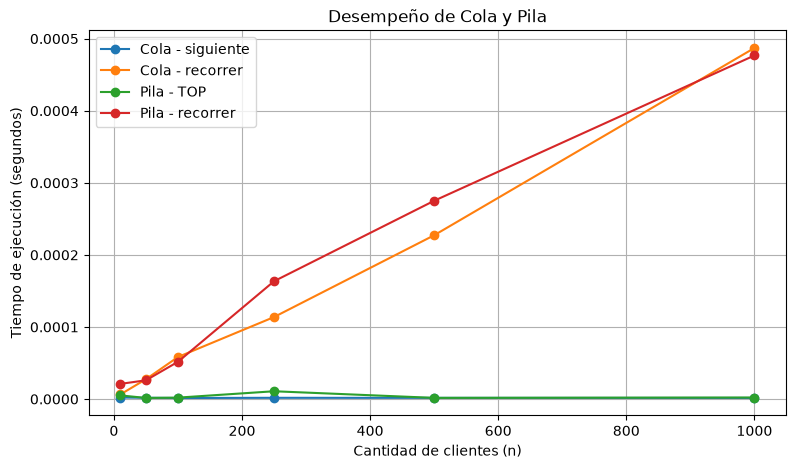

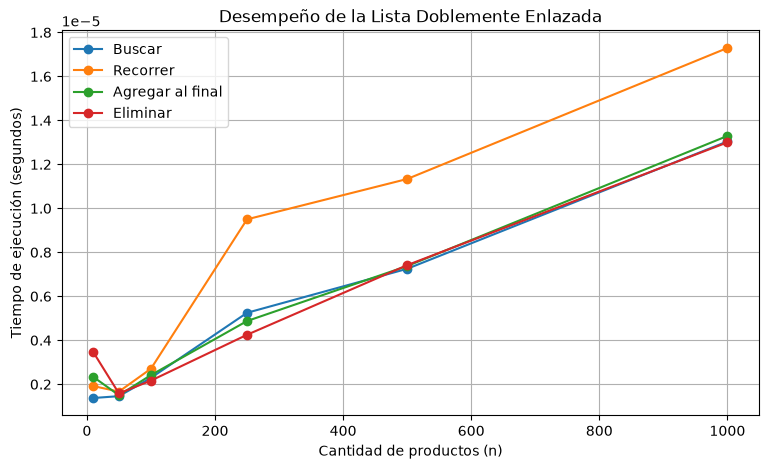


Prueba terminada correctamente.


In [91]:

import time
import matplotlib.pyplot as plt


# ============================================================
# 1. CONFIGURACIÓN
# ============================================================
#
# Probamos el sistema con diferentes cantidades de elementos.
# No usamos tamaños demasiado grandes para evitar que
# Jupyter tarde demasiado.
# ============================================================

tamanos = [10, 50, 100, 250, 500, 1000]

# Número de veces que repetimos cada operación.
repeticiones = 10


# ============================================================
# 2. FUNCIÓN PARA MEDIR TIEMPO PROMEDIO
# ============================================================

def medir_tiempo(funcion, repeticiones=10):
    """
    Ejecuta una función varias veces
    y devuelve su tiempo promedio.
    """

    inicio = time.perf_counter()

    for _ in range(repeticiones):
        funcion()

    fin = time.perf_counter()

    return (fin - inicio) / repeticiones


# ============================================================
# 3. PREPARAR CLIENTES PARA LAS PRUEBAS
# ============================================================
#
# Esta función crea rápidamente n clientes.
#
# atendidos = False:
# todos quedan en la COLA.
#
# atendidos = True:
# todos quedan en la PILA.
# ============================================================

def preparar_clientes_prueba(n, atendidos=False):

    conexion.execute("DELETE FROM clientes")

    datos = []

    for i in range(1, n + 1):

        if atendidos:
            estado = "atendido"
            orden_pila = i

        else:
            estado = "pendiente"
            orden_pila = None

        datos.append(
            (
                i,
                f"Cliente {i}",
                estado,
                i,
                orden_pila
            )
        )

    conexion.executemany("""
        INSERT INTO clientes
            (
                id_cliente,
                nombre,
                estado,
                orden_cola,
                orden_pila
            )
        VALUES (?, ?, ?, ?, ?)
    """, datos)

    conexion.commit()


# ============================================================
# 4. PREPARAR LISTA DOBLEMENTE ENLAZADA
# ============================================================
#
# Esta función crea una lista de prueba.
#
# Se construye directamente para que el tiempo de preparación
# NO afecte la medición de las operaciones que queremos probar.
# ============================================================

def crear_lista_prueba(n):

    lista = ListaDobleProductos()

    for i in range(1, n + 1):

        nuevo = NodoProducto(
            i,
            f"Producto {i}",
            1000
        )

        if lista.primero is None:

            lista.primero = nuevo
            lista.ultimo = nuevo

        else:

            nuevo.anterior = lista.ultimo

            lista.ultimo.siguiente = nuevo

            lista.ultimo = nuevo

    return lista


# ============================================================
# 5. DICCIONARIOS PARA GUARDAR RESULTADOS
# ============================================================

resultados_cola = {
    "Siguiente cliente": [],
    "Mostrar pendientes": []
}

resultados_pila = {
    "TOP / PEEK": [],
    "Mostrar atendidos": []
}

resultados_lista = {
    "Buscar": [],
    "Recorrer": [],
    "Agregar al final": [],
    "Eliminar": []
}


# ============================================================
# 6. PRUEBAS
# ============================================================

for n in tamanos:

    # ========================================================
    # PUNTO 1 - COLA
    # ========================================================

    preparar_clientes_prueba(
        n,
        atendidos=False
    )

    # ----------------------------------------
    # Consultar el primero de la cola
    # ----------------------------------------

    tiempo = medir_tiempo(
        siguiente_cliente,
        repeticiones
    )

    resultados_cola[
        "Siguiente cliente"
    ].append(tiempo)


    # ----------------------------------------
    # Obtener todos los pendientes
    # ----------------------------------------

    tiempo = medir_tiempo(
        obtener_pendientes,
        repeticiones
    )

    resultados_cola[
        "Mostrar pendientes"
    ].append(tiempo)


    # ========================================================
    # PUNTO 2 - PILA
    # ========================================================

    preparar_clientes_prueba(
        n,
        atendidos=True
    )

    # ----------------------------------------
    # TOP / PEEK
    # ----------------------------------------

    tiempo = medir_tiempo(
        top_cliente,
        repeticiones
    )

    resultados_pila[
        "TOP / PEEK"
    ].append(tiempo)


    # ----------------------------------------
    # Obtener toda la pila
    # ----------------------------------------

    tiempo = medir_tiempo(
        obtener_atendidos,
        repeticiones
    )

    resultados_pila[
        "Mostrar atendidos"
    ].append(tiempo)


    # ========================================================
    # PUNTO 3 - LISTA DOBLEMENTE ENLAZADA
    # ========================================================

    # ----------------------------------------
    # BUSCAR
    # ----------------------------------------
    #
    # Buscamos un código que NO existe.
    # Así obligamos a recorrer toda la lista:
    # es el peor caso.
    # ----------------------------------------

    lista = crear_lista_prueba(n)

    inicio = time.perf_counter()

    lista.buscar(n + 1)

    fin = time.perf_counter()

    resultados_lista[
        "Buscar"
    ].append(fin - inicio)


    # ----------------------------------------
    # RECORRER
    # ----------------------------------------

    lista = crear_lista_prueba(n)

    inicio = time.perf_counter()

    lista.recorrer_adelante()

    fin = time.perf_counter()

    resultados_lista[
        "Recorrer"
    ].append(fin - inicio)


    # ----------------------------------------
    # AGREGAR AL FINAL
    # ----------------------------------------
    #
    # En nuestro código agregar_final()
    # primero busca si el código ya existe.
    #
    # Por eso debe recorrer la lista.
    # ----------------------------------------

    lista = crear_lista_prueba(n)

    inicio = time.perf_counter()

    lista.agregar_final(
        n + 1,
        "Nuevo producto",
        5000
    )

    fin = time.perf_counter()

    resultados_lista[
        "Agregar al final"
    ].append(fin - inicio)


    # ----------------------------------------
    # ELIMINAR
    # ----------------------------------------
    #
    # Eliminamos el último producto.
    # Para encontrarlo se debe recorrer
    # prácticamente toda la lista.
    # ----------------------------------------

    lista = crear_lista_prueba(n)

    inicio = time.perf_counter()

    lista.eliminar(n)

    fin = time.perf_counter()

    resultados_lista[
        "Eliminar"
    ].append(fin - inicio)


# ============================================================
# 7. MOSTRAR RESULTADOS EN MILISEGUNDOS
# ============================================================

print("=" * 75)
print("PRUEBA DE DESEMPEÑO DEL SISTEMA")
print("=" * 75)


for i in range(len(tamanos)):

    n = tamanos[i]

    print(f"\nCantidad de elementos: {n}")

    print("-" * 55)

    print(
        "Cola - Siguiente cliente:",
        f"{resultados_cola['Siguiente cliente'][i] * 1000:.6f} ms"
    )

    print(
        "Cola - Mostrar pendientes:",
        f"{resultados_cola['Mostrar pendientes'][i] * 1000:.6f} ms"
    )

    print(
        "Pila - TOP / PEEK:",
        f"{resultados_pila['TOP / PEEK'][i] * 1000:.6f} ms"
    )

    print(
        "Pila - Mostrar atendidos:",
        f"{resultados_pila['Mostrar atendidos'][i] * 1000:.6f} ms"
    )

    print(
        "Lista - Buscar:",
        f"{resultados_lista['Buscar'][i] * 1000:.6f} ms"
    )

    print(
        "Lista - Recorrer:",
        f"{resultados_lista['Recorrer'][i] * 1000:.6f} ms"
    )

    print(
        "Lista - Agregar:",
        f"{resultados_lista['Agregar al final'][i] * 1000:.6f} ms"
    )

    print(
        "Lista - Eliminar:",
        f"{resultados_lista['Eliminar'][i] * 1000:.6f} ms"
    )


# ============================================================
# 8. GRÁFICA COLA Y PILA
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(
    tamanos,
    resultados_cola["Siguiente cliente"],
    marker="o",
    label="Cola - siguiente"
)

plt.plot(
    tamanos,
    resultados_cola["Mostrar pendientes"],
    marker="o",
    label="Cola - recorrer"
)

plt.plot(
    tamanos,
    resultados_pila["TOP / PEEK"],
    marker="o",
    label="Pila - TOP"
)

plt.plot(
    tamanos,
    resultados_pila["Mostrar atendidos"],
    marker="o",
    label="Pila - recorrer"
)

plt.xlabel("Cantidad de clientes (n)")
plt.ylabel("Tiempo de ejecución (segundos)")
plt.title("Desempeño de Cola y Pila")
plt.legend()
plt.grid(True)

plt.show()


# ============================================================
# 9. GRÁFICA LISTA DOBLEMENTE ENLAZADA
# ============================================================

plt.figure(figsize=(9, 5))

for operacion in resultados_lista:

    plt.plot(
        tamanos,
        resultados_lista[operacion],
        marker="o",
        label=operacion
    )

plt.xlabel("Cantidad de productos (n)")
plt.ylabel("Tiempo de ejecución (segundos)")
plt.title(
    "Desempeño de la Lista Doblemente Enlazada"
)
plt.legend()
plt.grid(True)

plt.show()


# ============================================================
# 10. RESTAURAR EL SISTEMA
# ============================================================

reiniciar_clientes([
    "Ana",
    "Carlos",
    "Laura",
    "Mateo"
])

actualizar_clientes(
    "Prueba de desempeño terminada. Sistema restaurado."
)

print("\nPrueba terminada correctamente.")